In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

In [6]:
# Load cleaned data
df = pd.read_csv('steam_ml_cleaned_data.csv').dropna()

print(df.shape)

# X: features (skipping first 3), y: target
X = df.iloc[:, 3:-1].copy()
y = df.iloc[:, -1]o

# split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# create histboost regressor with early stopping
hgb = HistGradientBoostingRegressor(
    random_state=1,
    early_stopping=True,
    n_iter_no_change=15,
    validation_fraction=0.1
)

# create parameter distribution to use with search for HGBR
param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 300, 500],
    'max_depth': [3, 5, 10, None],
    'l2_regularization': [0, 0.1, 1.0],
    'min_samples_leaf': [10, 25, 50]
}

# define scoring metrics for HGBR
scoring = {
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error'
}

# implement random search for histboost regressor with parameter distribution
# and five fold cross validation using scoring metrics with refit metric r2
random_search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_distributions,
    n_iter=40,                       
    scoring=scoring,
    cv=5,
    refit='R2',
    n_jobs=-1,
    verbose=1,
    random_state=21
)

random_search.fit(X_train, y_train)

(73451, 99)
(58760, 95)
Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,HistGradientB...andom_state=1)
,param_distributions,"{'l2_regularization': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'max_iter': [100, 300, ...], ...}"
,n_iter,40
,scoring,"{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,21
,error_score,nan


Top 5 Parameter Combinations:


,params,rank_test_R2,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_R2,std_test_R2,mean_test_MAE,std_test_MAE,mean_test_MSE,std_test_MSE
33,"{'min_samples_leaf': 50, 'max_iter': 500, 'max...",1,19.770755,1.608830,0.855885,0.048393,0.321532,0.005634,-0.123484,0.000734,-0.026646,0.000318
27,"{'min_samples_leaf': 25, 'max_iter': 500, 'max...",2,20.049379,2.688900,0.826099,0.090091,0.320093,0.005891,-0.123633,0.000876,-0.026703,0.000340
14,"{'min_samples_leaf': 25, 'max_iter': 500, 'max...",3,17.207594,1.513804,0.875950,0.203797,0.319849,0.005386,-0.123774,0.000722,-0.026712,0.000308
24,"{'min_samples_leaf': 25, 'max_iter': 500, 'max...",4,11.648073,1.698726,0.436906,0.058005,0.319108,0.006254,-0.123710,0.000963,-0.026742,0.000389
34,"{'min_samples_leaf': 25, 'max_iter': 500, 'max...",5,16.993407,2.379954,0.915028,0.389411,0.319100,0.005612,-0.123787,0.000927,-0.026742,0.000346


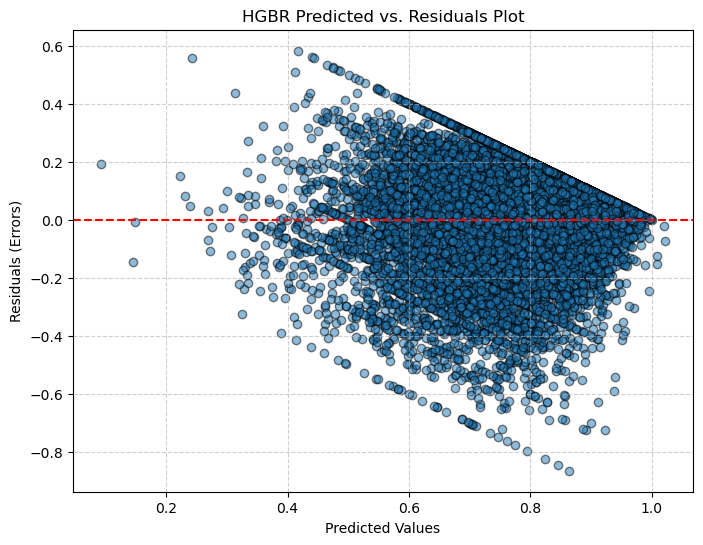

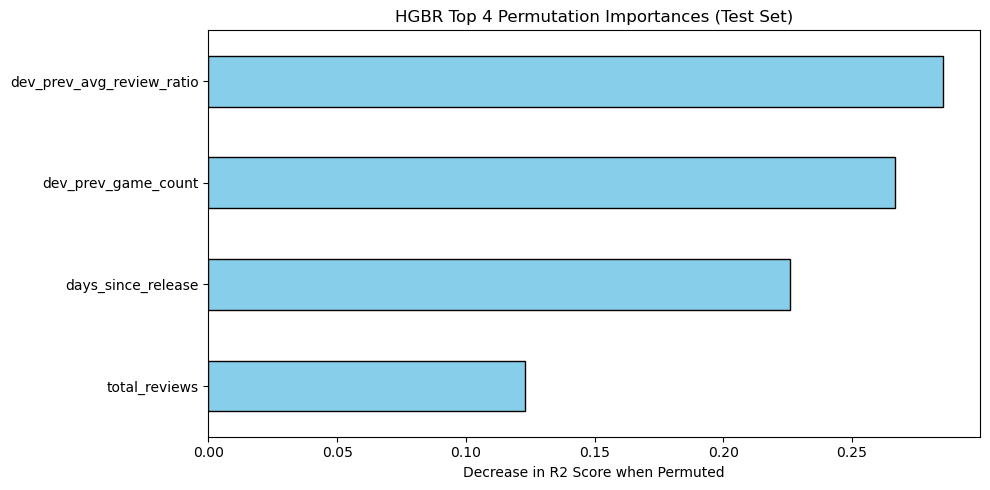

C:\Users\mattf\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 16 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\mattf\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


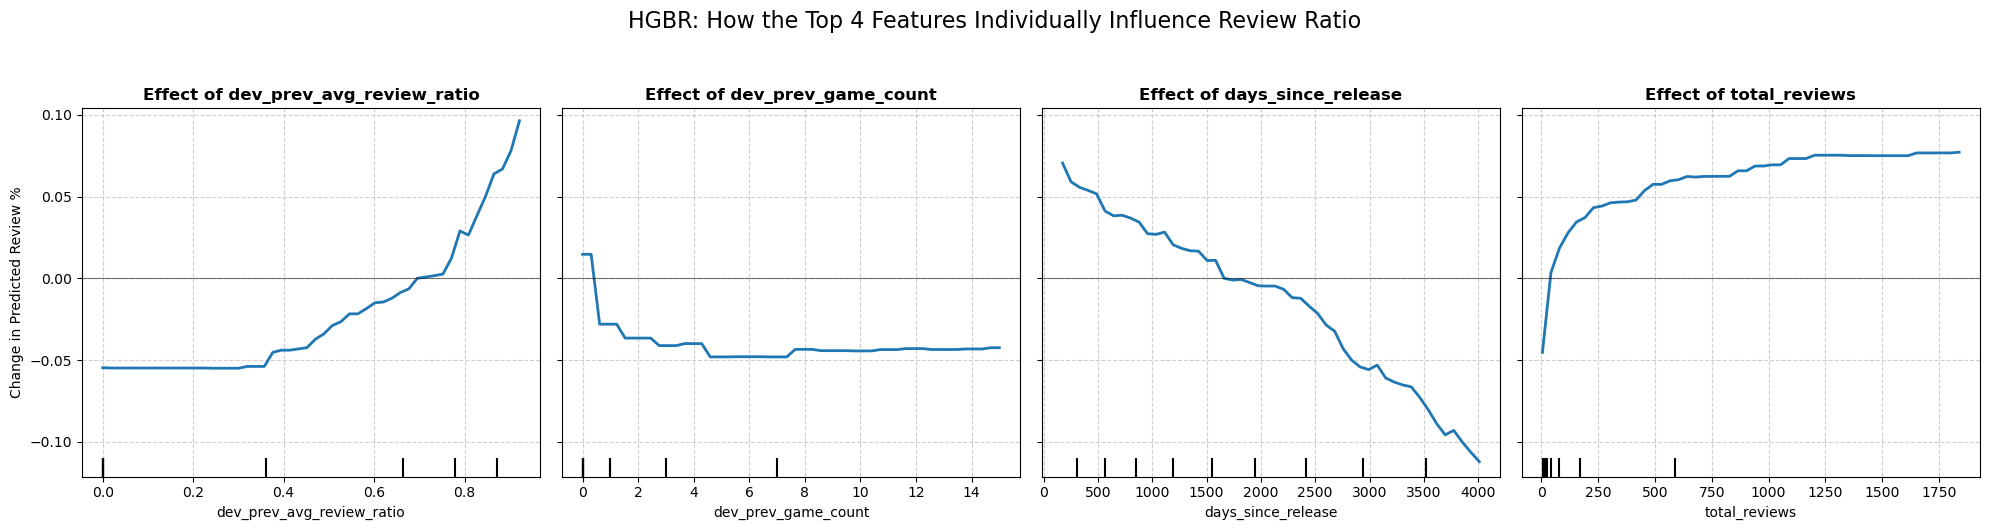

C:\Users\mattf\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 16 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\mattf\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 16 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


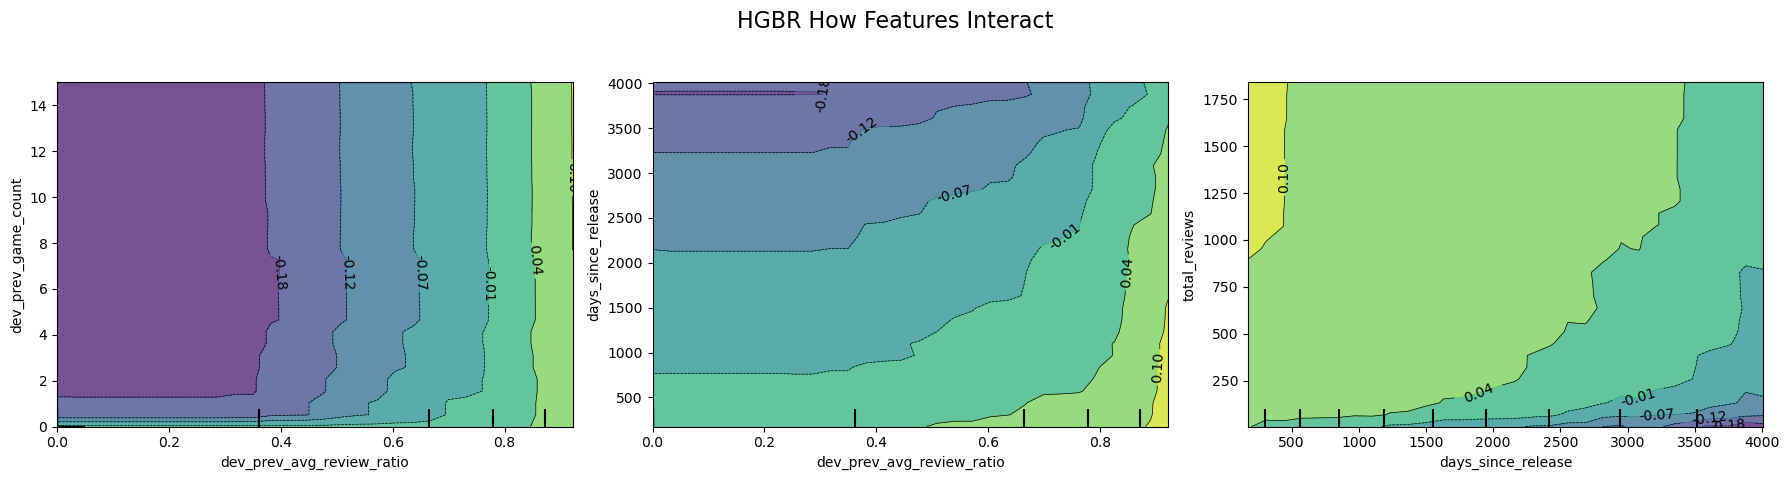

In [8]:
# Results Table for Parameters
results_df = pd.DataFrame(random_search.cv_results_)
relevant_columns = ['params', 'rank_test_R2']
score_cols = [col for col in results_df.columns if 'mean_' in col or 'std_' in col]
relevant_columns.extend(score_cols)
display_table = results_df[relevant_columns].sort_values('rank_test_R2')
print("Top 5 Parameter Combinations:")
display(display_table.head())

# Predicted vs Residuals Graph
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('HGBR Predicted vs. Residuals Plot')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# top four feature importance bar graph (permutationo-based)
feature_names = X.columns.tolist()
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=7)

importances = pd.Series(perm_importance.importances_mean, index=feature_names)
sorted_importances = importances.sort_values()
top_4_importances = sorted_importances.tail(4)
top_4_importances.plot(
    kind='barh', 
    title='HGBR Top 4 Permutation Importances (Test Set)',
    figsize=(10, 5),
    color='skyblue',
    edgecolor='black'
)
plt.xlabel("Decrease in R2 Score when Permuted")
plt.tight_layout()
plt.show()
top_4_features = top_4_importances.sort_values(ascending=False).index.tolist()

# create partial dependence plots for top four features
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

display1d = PartialDependenceDisplay.from_estimator(
    best_model, 
    X_train, 
    features=top_4_features,
    feature_names=X.columns.tolist(), 
    ax=axes,
    grid_resolution=50,
    line_kw={"color": "tab:blue", "linewidth": 2}
)

#  plot partial dependence plots with labels
for i, ax in enumerate(axes):
    ax.set_title(f'Effect of {top_4_features[i]}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Change in Predicted Review %' if i==0 else "")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.suptitle('HGBR: How the Top 4 Features Individually Influence Review Ratio', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# create partial dependence plot for interactions between top feature and 2-4 features
interactions = [
    (top_4_features[0], top_4_features[1]),
    (top_4_features[0], top_4_features[2]),
    (top_4_features[2], top_4_features[3])
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
PartialDependenceDisplay.from_estimator(
    best_model, 
    X_train, 
    features=interactions, 
    feature_names=feature_names,
    ax=axes,
    grid_resolution=30
)
# plot partial dependence plot with label
plt.suptitle('HGBR How Features Interact', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()